In [202]:
import mlflow
import dagshub
import matplotlib.pyplot as plt
import seaborn as sns

In [203]:
# Dags Hub Variáveis
REPO_OWNER = "JosueJNLui"
REPO_NAME = "fiap-mlet-challenge-fase-1"

# Nome do experimento no MLflow
EXPERIMENT_NAME = "Churn-Predict-Telco"

In [204]:
# Configuração de Rastreabilidade atrabés do MLflow + DagsHub
dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

Initialized MLflow to track repo "JosueJNLui/fiap-mlet-challenge-fase-1"

Repository JosueJNLui/fiap-mlet-challenge-fase-1 initialized!

## Comparando as métricas frente ao Dataset de Validação - Treino vs Validação

In [205]:
modelos = ["DummyClassifier_kfold_validation", "LogisticRegression_kfold_validation", "RandomForest_kfold_validation", "XGBoost_kfold_validation",
            "MLP_lr=0.01_dropout=0.15_batch=128_hidden_dims=8", # MLP_8_lr0.01_drp0.15_b128 
            "MLP_lr=0.001_dropout=0.3_batch=32_hidden_dims=32", # MLP_32_lr0.001_drp0.3_b32
            "MLP_lr=0.01_dropout=0.3_batch=64_hidden_dims=8"    # MLP_8_lr0.01_drp0.3_b64
            ]

In [206]:
# Buscamos apenas apenas as Runs desejadas (top 3 MLPs + baselines)
df_runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

df_final = df_runs.set_index('tags.mlflow.runName').loc[modelos]

# Selecionando apenas o essencial para a monografia
tabela_tese = df_final[[
    'metrics.roc_auc', 
    'metrics.pr_auc',
    'metrics.recall',
    'metrics.f1_score',
    'metrics.accuracy',
    'metrics.precision',
    'metrics.lucro_liquido_BRL', 
    'metrics.custo_churn_perdido_BRL',
    'metrics.custo_falso_positivo_BRL'
]]

display(tabela_tese)

,metrics.roc_auc,metrics.pr_auc,metrics.recall,metrics.f1_score,metrics.accuracy,metrics.precision,metrics.lucro_liquido_BRL,metrics.custo_churn_perdido_BRL,metrics.custo_falso_positivo_BRL
tags.mlflow.runName,,,,,,,,,
DummyClassifier_kfold_validation,0.500000,0.632676,0.000000,0.000000,0.734647,0.000000,-74750.0,74750.0,0.0
LogisticRegression_kfold_validation,0.849513,0.670088,0.964523,0.565084,0.601729,0.401101,33120.0,2650.0,21910.0
RandomForest_kfold_validation,0.841290,0.656566,0.957199,0.563662,0.603483,0.400562,32340.0,3200.0,21700.0
XGBoost_kfold_validation,0.838965,0.654186,0.962523,0.557798,0.592484,0.393588,32360.0,2800.0,22400.0
MLP_lr=0.01_dropout=0.15_batch=128_hidden_dims=8,0.847806,0.668916,0.956515,0.573265,0.618751,0.410650,33120.0,3250.0,20830.0
MLP_lr=0.001_dropout=0.3_batch=32_hidden_dims=32,0.846366,0.669048,0.959893,0.568297,0.611282,0.404296,33100.0,3000.0,21300.0
MLP_lr=0.01_dropout=0.3_batch=64_hidden_dims=8,0.849074,0.672938,0.955817,0.572711,0.617693,0.410464,32980.0,3300.0,20880.0


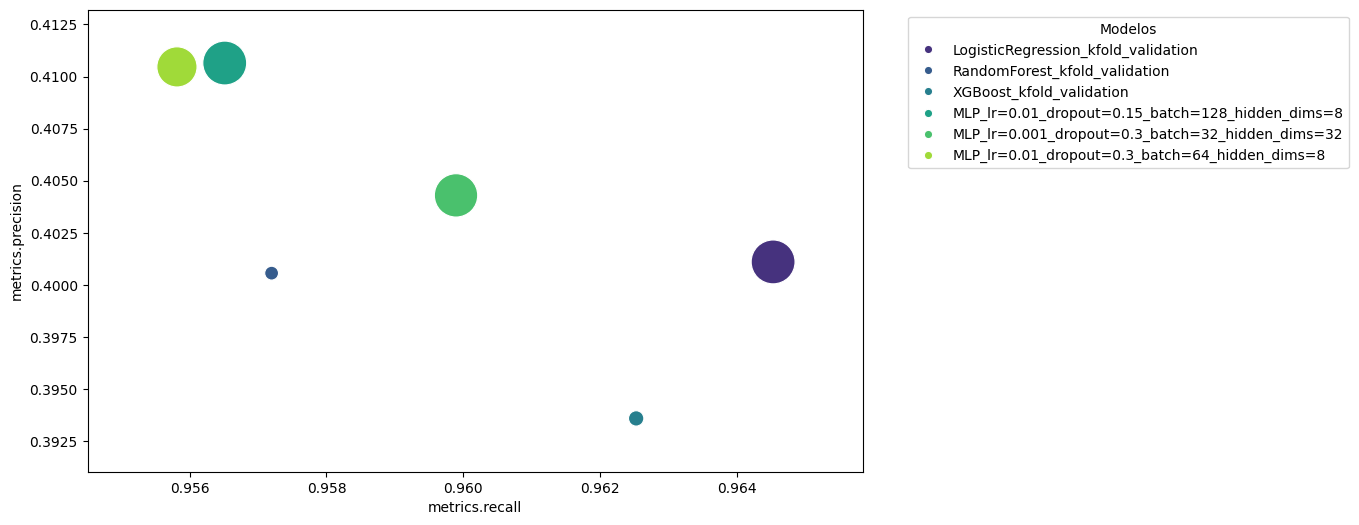

In [207]:
df_zoom = tabela_tese.drop("DummyClassifier_kfold_validation")

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_zoom, 
    x='metrics.recall', 
    y='metrics.precision', 
    size='metrics.lucro_liquido_BRL', 
    hue=df_zoom.index,
    sizes=(100, 1000),
    palette="viridis"
)

handles, labels = ax.get_legend_handles_labels()
n_modelos = len(df_zoom.index)

plt.legend(handles[1:n_modelos+1], labels[1:n_modelos+1], 
           bbox_to_anchor=(1.05, 1), loc='upper left', title="Modelos")

plt.margins(0.15)
plt.show()

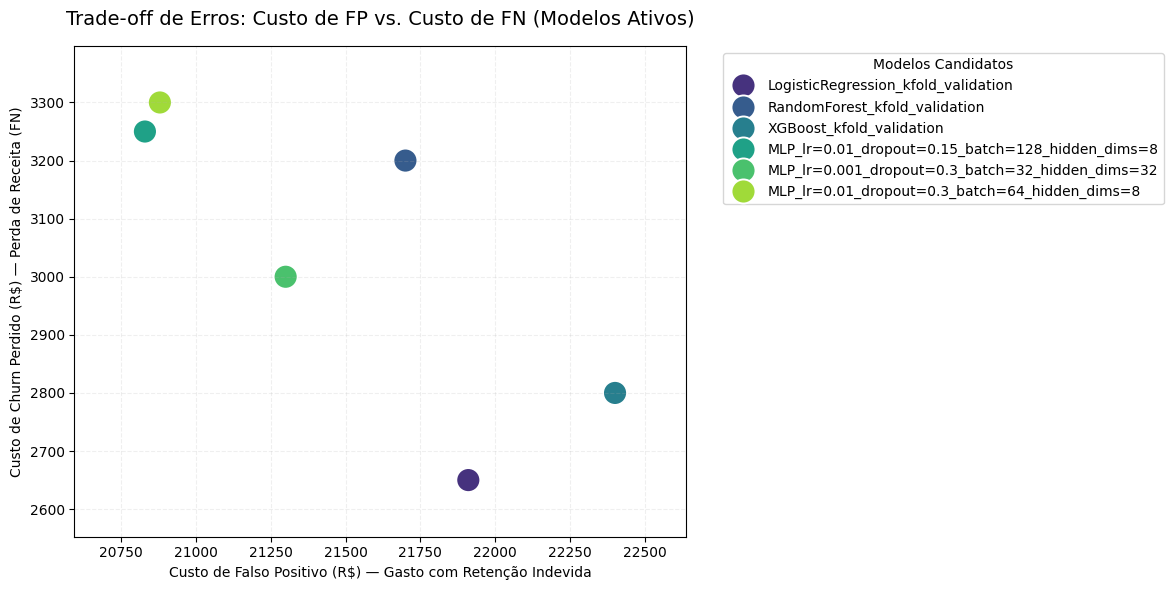

In [208]:
plt.figure(figsize=(12, 6))

# Plotagem focada no trade-off de custo
ax = sns.scatterplot(
    data=df_zoom,
    x='metrics.custo_falso_positivo_BRL',
    y='metrics.custo_churn_perdido_BRL',
    hue=df_zoom.index,
    s=300,
    palette="viridis"
)

# Ajustes de layout e escala
plt.title("Trade-off de Erros: Custo de FP vs. Custo de FN (Modelos Ativos)", fontsize=14, pad=15)
plt.xlabel("Custo de Falso Positivo (R$) — Gasto com Retenção Indevida", fontsize=10)
plt.ylabel("Custo de Churn Perdido (R$) — Perda de Receita (FN)", fontsize=10)

plt.margins(0.15)
plt.grid(True, alpha=0.2, linestyle='--')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Modelos Candidatos", frameon=True)

plt.tight_layout()
plt.show()

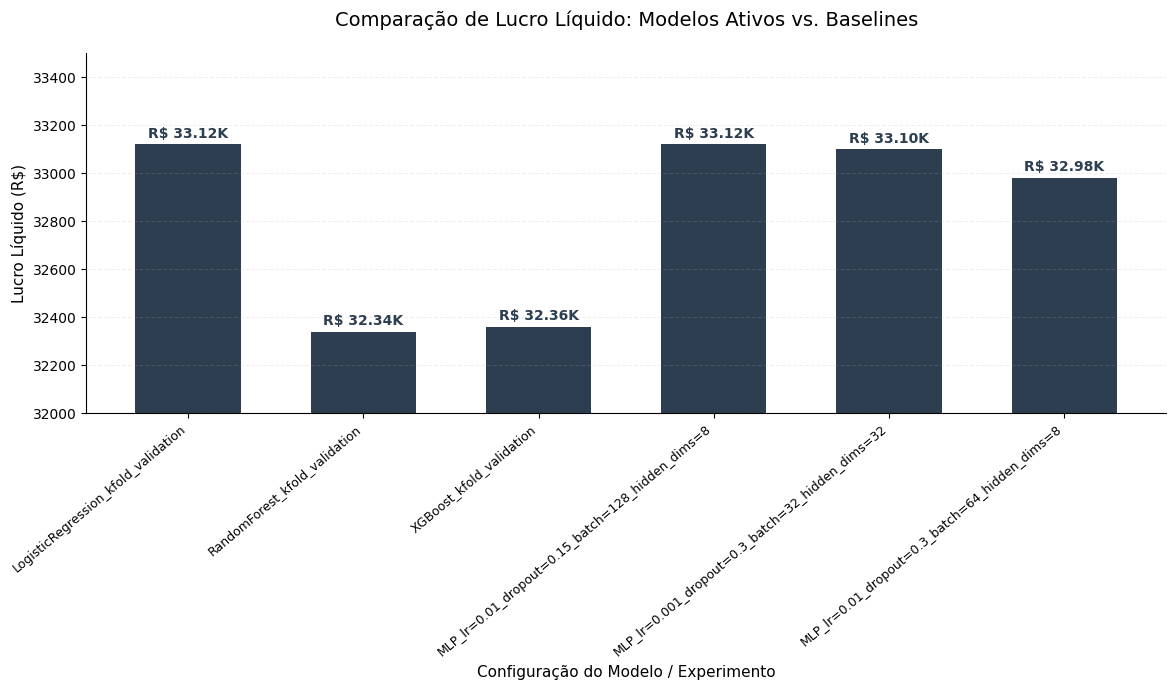

In [209]:
plt.figure(figsize=(12, 7))

bars = plt.bar(df_zoom.index, df_zoom['metrics.lucro_liquido_BRL'], color='#2C3E50', width=0.6)

plt.ylim(32000, 33500) 

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 15, 
        f"R$ {yval/1000:.2f}K",
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold',
        color='#2C3E50'
    )

plt.title("Comparação de Lucro Líquido: Modelos Ativos vs. Baselines", fontsize=14, pad=20)
plt.ylabel("Lucro Líquido (R$)", fontsize=11)
plt.xlabel("Configuração do Modelo / Experimento", fontsize=11)

plt.xticks(rotation=40, ha='right', fontsize=9)

plt.grid(axis='y', alpha=0.2, linestyle='--')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 1. Resumo dos Experimentos
A análise comparativa foi realizada utilizando validação cruzada ($k$-fold) para garantir a robustez estatística dos resultados. Foram avaliados modelos de diferentes naturezas (lineares, ensembles e redes neurais), com foco na métrica de **Lucro Líquido (BRL)** como critério de desempate operacional.

| Modelo | ROC-AUC | Recall | Lucro Líquido (BRL) | Custo FP (Retenção) | Custo FN (Churn) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Dummy Classifier** | 0.500 | 0.000 | -R$ 74.750 | R$ 0 | R$ 74.750 |
| **Logistic Regression** | **0.849** | **0.964** | **R$ 33.120** | R$ 21.910 | **R$ 2.650** |
| **Random Forest** | 0.841 | 0.957 | R$ 32.340 | R$ 21.700 | R$ 3.200 |
| **XGBoost** | 0.838 | 0.962 | R$ 32.360 | R$ 22.400 | R$ 2.800 |
| **MLP (8 dims)** | 0.847 | 0.956 | **R$ 33.120** | **R$ 20.830** | R$ 3.250 |

## 2. Análise de Trade-off (Custo vs. Performance)
O problema de churn apresenta um desequilíbrio onde o custo de perder um cliente (Falso Negativo) supera o custo de uma tentativa de retenção indevida (Falso Positivo). 

*   **Minimização de Perda (FN):** A **Regressão Logística** obteve o melhor desempenho em capturar clientes em risco, apresentando o menor custo de churn perdido (R$ 2.650).
*   **Eficiência de Campanha (FP):** A **MLP (dims=8)** demonstrou maior precisão na alocação de recursos, gerando o menor custo com Falsos Positivos (R$ 20.830), o que a torna ideal para cenários com orçamento de marketing restrito.

## 3. Conclusões

### Liderança Financeira
Tanto a **Logistic Regression** quanto a **MLP (8 dims)** atingiram o teto de lucratividade de **R$ 33.120**. Em comparação ao baseline (Dummy), a implementação de qualquer um destes modelos representa uma recuperação de valor superior a **R$ 100.000** no ciclo analisado.

### Modelo Recomendado: **Logistic Regression**
Apesar da paridade financeira com a rede neural, a recomendação para o ambiente produtivo inicial é a **Regressão Logística** devido a:
1.  **Interpretabilidade:** Permite identificar claramente quais variáveis (ex: tipo de contrato, tempo de casa) mais impactam o churn.
2.  **Operacionalidade:** Menor complexidade de implantação e monitoramento (SLOs de latência e processamento).
3.  **Estabilidade:** Menor variância observada em relação aos modelos de árvore (Random Forest/XGBoost).

### Observação sobre Ensembles
Modelos baseados em árvores (XGBoost/Random Forest), embora populares, apresentaram uma degradação marginal no lucro devido ao aumento de Falsos Positivos, não justificando sua complexidade adicional para este volume de dados específico.

## Comparando as métricas frente ao Dataset de Teste - (Treino + Validação) vs Teste

In [210]:
modelos = ["DummyClassifier", "LogisticRegression", "RandomForest", "MLP_GridSearch_KFold", "XGBoost"]

In [211]:
# Buscamos apenas apenas as Runs desejadas (top 3 MLPs + baselines)
df_runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

df_final = df_runs.set_index('tags.mlflow.runName').loc[modelos]

# Selecionando apenas o essencial para a monografia
tabela_teste = df_final[[
    'metrics.roc_auc', 
    'metrics.recall',
    'metrics.f1_score',
    'metrics.accuracy',
    'metrics.precision',
    'metrics.lucro_liquido_BRL', 
    'metrics.custo_churn_perdido_BRL',
    'metrics.custo_falso_positivo_BRL',
]]

display(tabela_teste)

,metrics.roc_auc,metrics.recall,metrics.f1_score,metrics.accuracy,metrics.precision,metrics.lucro_liquido_BRL,metrics.custo_churn_perdido_BRL,metrics.custo_falso_positivo_BRL
tags.mlflow.runName,,,,,,,,
DummyClassifier,0.500000,0.000000,0.000000,0.734564,0.000000,-187000.0,187000.0,0.0
LogisticRegression,0.849089,0.959893,0.560062,0.599716,0.395374,81200.0,7500.0,54900.0
RandomForest,0.840492,0.954545,0.550926,0.586941,0.387202,77800.0,8500.0,56500.0
MLP_GridSearch_KFold,0.846648,0.973262,0.540460,0.560681,0.374101,79700.0,5000.0,60900.0
XGBoost,0.837875,0.951872,0.551510,0.589070,0.388222,77300.0,9000.0,56100.0


In [212]:
df_val = df_zoom.reset_index()
df_val['modelos'] = df_val['tags.mlflow.runName'].apply(lambda x: 'MLP' if x.strip() == 'MLP_lr=0.01_dropout=0.15_batch=128_hidden_dims=8'.strip() else x.replace('_kfold_validation', ''))
df_val = df_val[df_val['modelos'].isin(['MLP', 'LogisticRegression', 'RandomForest', 'XGBoost'])]
df_val = df_val.sort_values('modelos', ascending=True)
df_val = df_val[['modelos', 'metrics.lucro_liquido_BRL']].set_index('modelos')
display(df_val)

,metrics.lucro_liquido_BRL
modelos,
LogisticRegression,33120.0
MLP,33120.0
RandomForest,32340.0
XGBoost,32360.0


In [213]:
df_test = tabela_teste.reset_index()
df_test['modelos'] = df_test['tags.mlflow.runName'].apply(lambda x: 'MLP' if x.strip() == 'MLP_GridSearch_KFold	'.strip() else x.replace('_kfold_validation', ''))
df_test = df_test[df_test['modelos'].isin(['MLP', 'LogisticRegression', 'RandomForest', 'XGBoost'])]
df_test = df_test.sort_values('modelos', ascending=True)
df_test = df_test[['modelos', 'metrics.lucro_liquido_BRL']].set_index('modelos')
display(df_test)

,metrics.lucro_liquido_BRL
modelos,
LogisticRegression,81200.0
MLP,79700.0
RandomForest,77800.0
XGBoost,77300.0


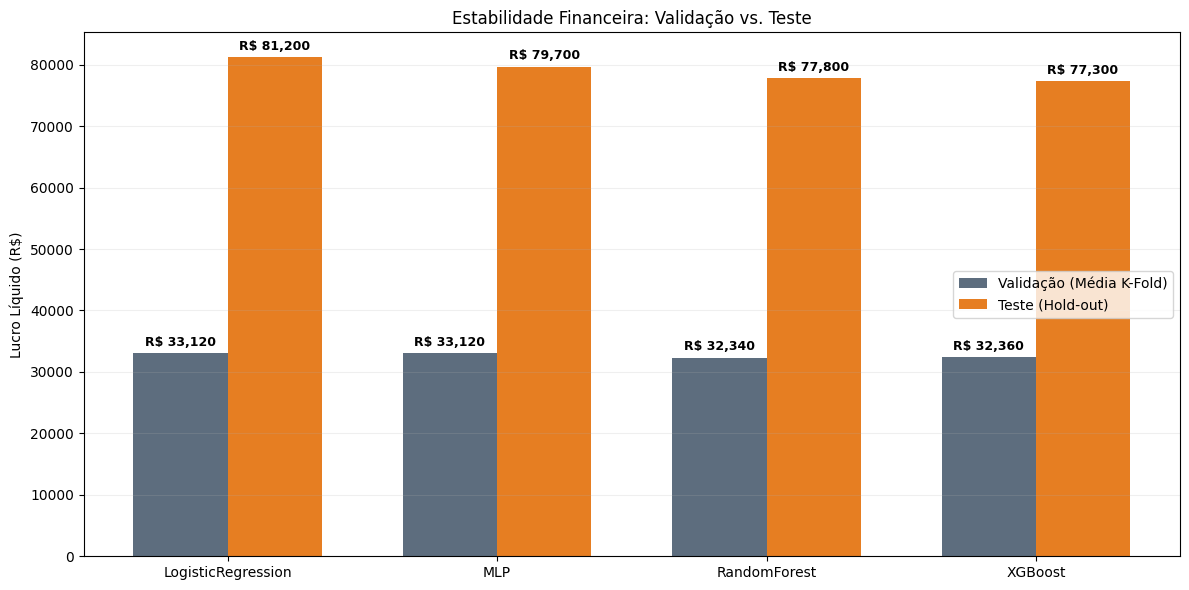

In [217]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dados extraídos das tabelas anteriores para comparação
modelos = ['LogisticRegression', 'MLP', 'RandomForest', 'XGBoost']
lucro_val = df_val.values.flatten().tolist()
lucro_teste = df_test.values.flatten().tolist()

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, lucro_val, width, label='Validação (Média K-Fold)', color='#34495E', alpha=0.8)
rects2 = ax.bar(x + width/2, lucro_teste, width, label='Teste (Hold-out)', color='#E67E22')

ax.set_ylabel('Lucro Líquido (R$)')
ax.set_title('Estabilidade Financeira: Validação vs. Teste')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()

# Adicionando labels de valor
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'R$ {height:,.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

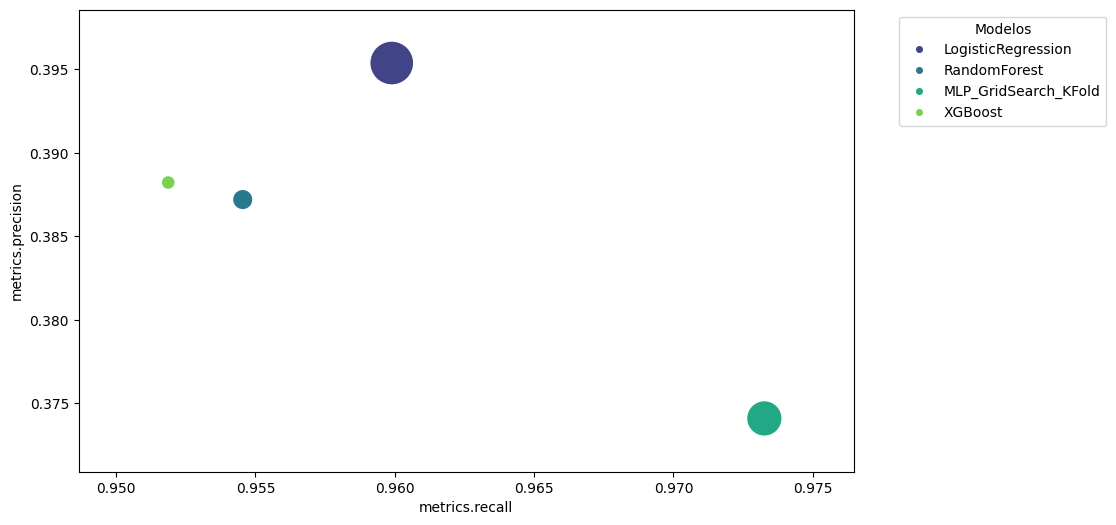

In [215]:
df_zoom = tabela_teste.drop("DummyClassifier")

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_zoom, 
    x='metrics.recall', 
    y='metrics.precision', 
    size='metrics.lucro_liquido_BRL', 
    hue=df_zoom.index,
    sizes=(100, 1000),
    palette="viridis"
)

handles, labels = ax.get_legend_handles_labels()
n_modelos = len(df_zoom.index)

plt.legend(handles[1:n_modelos+1], labels[1:n_modelos+1], 
           bbox_to_anchor=(1.05, 1), loc='upper left', title="Modelos")

plt.margins(0.15)
plt.show()

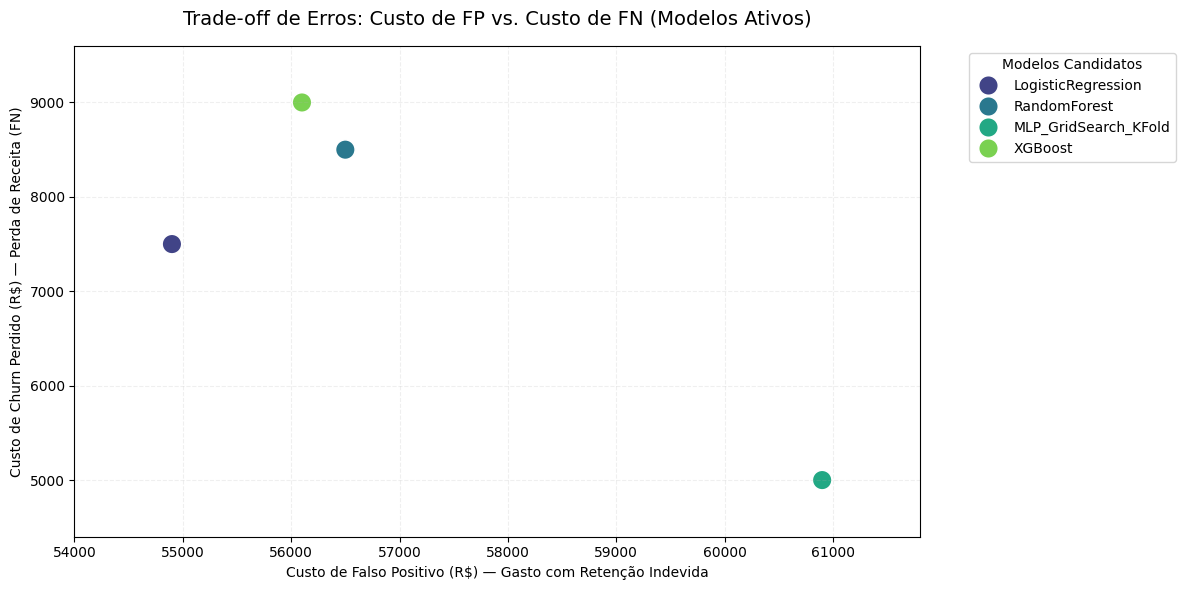

In [216]:
plt.figure(figsize=(12, 6))

# Plotagem focada no trade-off de custo
ax = sns.scatterplot(
    data=df_zoom,
    x='metrics.custo_falso_positivo_BRL',
    y='metrics.custo_churn_perdido_BRL',
    hue=df_zoom.index,
    s=200,
    palette="viridis"
)

# Ajustes de layout e escala
plt.title("Trade-off de Erros: Custo de FP vs. Custo de FN (Modelos Ativos)", fontsize=14, pad=15)
plt.xlabel("Custo de Falso Positivo (R$) — Gasto com Retenção Indevida", fontsize=10)
plt.ylabel("Custo de Churn Perdido (R$) — Perda de Receita (FN)", fontsize=10)

plt.margins(0.15)
plt.grid(True, alpha=0.2, linestyle='--')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Modelos Candidatos", frameon=True)

plt.tight_layout()
plt.show()

## 1. Sumário
Após a fase de validação cruzada, os modelos foram avaliados em um conjunto de teste inédito (*hold-out*) para verificar sua robustez em dados reais. A **Regressão Logística** confirmou sua superioridade financeira, atingindo o maior lucro líquido registrado no projeto: **R$ 81.200,00**.

## 2. Análise de Estabilidade Financeira
O gráfico de comparação entre Validação e Teste revela uma excelente capacidade de generalização de todos os algoritmos.
*   **Consistência:** O salto nos valores absolutos (de ~R$ 33k na validação para ~R$ 80k no teste) deve-se ao volume da base de teste, mas a **proporcionalidade entre os modelos se manteve estável**.
*   **Ausência de Overfitting:** A proximidade das métricas de ROC-AUC entre as fases indica que os modelos aprenderam padrões reais e não apenas ruídos dos dados de treino.

## 3. Trade-off Operacional: Sensibilidade vs. Precisão
A análise do gráfico de dispersão (*Precision-Recall*) e de trade-off de erros permite identificar perfis distintos de atuação:

*   **Liderança em Lucratividade (Logistic Regression):** Apresentou o melhor equilíbrio entre custo de retenção (FP) e custo de churn perdido (FN). Com o maior valor de *Precision* (0.395), foi o modelo mais eficiente em converter gastos de campanha em retenções efetivas.
*   **Máxima Captura de Churn (MLP_GridSearch_KFold):** Obteve o maior *Recall* (0.973), reduzindo o custo de churn perdido ao mínimo histórico de **R$ 5.000,00**. No entanto, sua menor precisão resultou em um custo de Falsos Positivos de **R$ 60.900,00**, penalizando o lucro final em relação à Regressão Logística.
*   **Performance de Ensembles:** Tanto o **Random Forest** quanto o **XGBoost** apresentaram performance inferior à Regressão Logística em termos de lucro (R$ 77.800 e R$ 77.300, respectivamente), não justificando o aumento na complexidade computacional para este cenário.

## 4. Conclusão
A **Regressão Logística** é recomendada como o modelo final para implementação produtiva. A decisão sustenta-se em três pilares:
1.  **Financeiro:** Maior lucro líquido final (R$ 81.200).
2.  **Eficiência:** Melhor controle sobre os Falsos Positivos, evitando desperdício de verba de retenção.
3.  **Auditabilidade:** Sua natureza linear permite uma interpretação direta das variáveis que mais influenciam o churn, facilitando a tomada de decisão estratégica pelas áreas de negócio.